In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pickle
from src.operations2d import ImageChunk
from src.util import (
    read_video_frames,
    display_image,
    get_character_placeholder,
    read_trimesh,
    trimesh_to_opencv,
    opencv_to_trimesh_pose,
)
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, find_similar_image_chunk
from src.operations3d import get_intrinsics_for_chunk, apply_mesh_transforms, adjust_transforms_by_chunk_rotation

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frames = read_video_frames(video_path)
previous_frame = frames[0]
next_frame = frames[1]

In [4]:
# read mesh data from pkl
input_pkl = "output/wooden_cabinet.pkl"
with open(input_pkl, 'rb') as f:
            frames_data = pickle.load(f)
            
class_data = frames_data[0]["classes"][0]
object_class = class_data["class_name"]
mesh_data = class_data["reconstructed_meshes"][0]

unposed_path = mesh_data.get("unposed_mesh_path")
scale = mesh_data.get("scale")
rotation = mesh_data.get("rotation")
translation = mesh_data.get("translation")

chunk_relative_scale = mesh_data.get("chunk_relative_scale")
chunk_relative_rotation = mesh_data.get("chunk_relative_rotation")
chunk_relative_translation = mesh_data.get("chunk_relative_translation")

image_chunk_center = mesh_data.get("image_chunk_center")
image_chunk_size = mesh_data.get("image_chunk_size")

Detect objects and get image chunk that is close to previous one

In [5]:
next_image_chunk = ImageChunk.from_image_point(previous_frame, image_chunk_center, image_chunk_size)

In [6]:
bounding_boxes = get_2d_bounding_boxes(next_frame, object_class, use_gpu=True)

/work/RA/instruct360/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
import pkg_resources
[sam3_worker] Loading SAM3 model...
[sam3_worker] SAM3 model loaded.


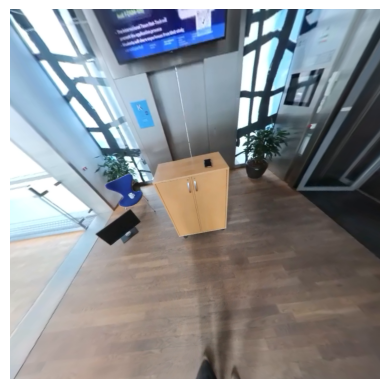

In [ ]:
image_chunks = bounding_boxes_to_image_chunks(next_frame, bounding_boxes, orientation="horizontal")
next_next_image_chunk = find_similar_image_chunk(previous_image_chunk, image_chunks)
display_image(next_image_chunk.image)

In [11]:
import numpy as np
K = np.array([[395.27175903,   0.        , 350.        ],
       [  0.        , 395.27175903, 350.        ],
       [  0.        ,   0.        ,   1.        ]])

Get object mesh in previous pose relative to camera in OpenCV format

In [17]:
import numpy as np

unposed_mesh = read_trimesh(unposed_path)
identity_rotation = np.eye(3, dtype=np.float32)
zero_translation = np.zeros(3, dtype=np.float32)
scaled_mesh = apply_mesh_transforms(unposed_mesh, identity_rotation, zero_translation, chunk_relative_scale)


In [18]:
import cv2

cv_vertices, cv_tris, cv_rotation_mat, cv_translation = trimesh_to_opencv(
    scaled_mesh,
    rotation_matrix=mesh_data.get("chunk_relative_rotation"),
    translation_vector=mesh_data.get("chunk_relative_translation"),
)

cv_rotation, _ = cv2.Rodrigues(cv_rotation_mat)

Run RAPID and apply new transforms to object

In [19]:
# extract contour points
contour_points_2d, contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation,
    cv_translation,
    K,
    next_image_chunk.image.shape[:2],
    cv_tris,
)

In [20]:
# get the center point in 2d
center_2d = np.mean(contour_points_2d, axis=0)[0]
center_2d

array([353.49646, 366.8363 ], dtype=float32)

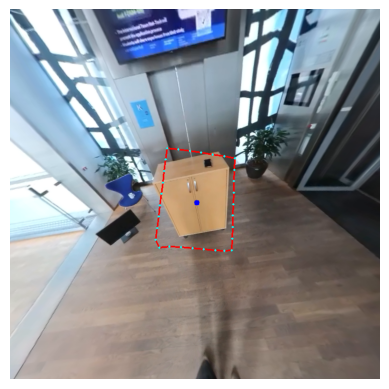

In [27]:
# visualize contour points
contour_overlay = next_image_chunk.image.copy()

contour = contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(contour_overlay, [contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in contour:
    cv2.circle(contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
cv2.circle(contour_overlay, tuple(center_2d.astype(int)), 5, (0, 0, 255), -1)

display_image(contour_overlay)

Do FoundationPose inference to estimate next pose

In [14]:
from src.operations3d import estimate_pose_for_image_chunk
next_rotation_chunk, next_translation_chunk, center_rotation, center_translation = estimate_pose_for_image_chunk(
    chunk=next_image_chunk,
    unposed_mesh_path=unposed_path,
    class_name=object_class,
    K=K,
    is_first_frame=True,
    da_env="da"
)

Running da_worker in conda environment 'da'...
[da_worker] depth units=mm shape=(700, 700) min=0.0000 max=255.0000 mean=118.4992 p05=34.0000 p50=118.0000 p95=202.0000 center=116.0000

[depth] units=mm shape=(700, 700) min=0.0000 max=255.0000 mean=118.4992 p50=118.0000 center=116.0000
[reset_object()] self.diameter:1.2711564909196753, vox_size:0.06355782454598377
[reset_object()] self.pts:torch.Size([659, 3])
[reset_object()] reset done
[make_rotation_grid()] cam_in_obs:(42, 4, 4)
[make_rotation_grid()] rot_grid:(252, 4, 4)
num original candidates = 252
num of pose after clustering: 252
[make_rotation_grid()] after cluster, rot_grid:(252, 4, 4)
[make_rotation_grid()] self.rot_grid: torch.Size([252, 4, 4])
[register()] Welcome
[register()] poses:(252, 4, 4)
[register()] after viewpoint, add_errs min:-1.0
[predict()] ob_in_cams:(252, 4, 4)
[predict()] self.cfg.use_normal:False
[predict()] trans_normalizer:[0.019999999552965164, 0.019999999552965164, 0.05000000074505806], rot_normalizer:0.

RuntimeError: Persistent worker terminated unexpectedly
Worker logs:
warmup_step: -1
input_resize:
- 160
- 160
max_step_val: 1000
vis_interval: 1000
weight_decay: 0
normalize_xyz: true
resume_run_id: null
clip_grad_norm: 'Infinity'
lr_epoch_decay: 500
render_backend: nvdiffrast
train_num_pair: 5
lr_decay_epochs:
- 50
n_epochs_warmup: 1
make_pair_online: false
gradient_max_norm: 'Infinity'
max_step_per_epoch: 10000
n_rendering_workers: 1
save_epoch_interval: 100
n_dataloader_workers: 100
split_objects_across_gpus: true
ckpt_dir: /work/RA/instruct360/FoundationPose/learning/training/../../weights/2024-01-11-20-02-45/model_best.pth

[__init__()] self.h5_file:None
[__init__()] Using pretrained model from /work/RA/instruct360/FoundationPose/learning/training/../../weights/2024-01-11-20-02-45/model_best.pth
[__init__()] init done
[__init__()] welcome
[__init__()] self.cfg: 
 lr: 0.0001
c_in: 6
zfar: .inf
debug: null
w_rot: 0.1
n_view: 1
run_id: null
use_BN: true
rot_rep: axis_angle
ckpt_dir:

In [13]:
next_translation_chunk

array([0., 0., 0.], dtype=float32)

In [12]:
# Pose in world
rot, trans = adjust_transforms_by_chunk_rotation([next_rotation_chunk], [next_translation_chunk], next_image_chunk)
next_rotation_world = rot[0]
next_translation_world = trans[0]

Visualize pose difference

In [13]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, rotation, translation, scale)

In [14]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])

Get next chunk

In [21]:
h, w = next_image_chunk.image.shape[:2]
offset_x = center_2d[0] / w - 0.5
offset_y = center_2d[1] / h - 0.5
next_contour_center = (next_image_chunk.center[0] + offset_x, next_image_chunk.center[1] + offset_y)
next_next_image_chunk = ImageChunk.from_image_point(frames[2], next_contour_center, (700, 700))

In [22]:
cv_vertices, cv_tris, cv_rotation_mat_new, cv_translation_new = trimesh_to_opencv(
    scaled_mesh,
    rotation_matrix=next_rotation_chunk,
    translation_vector=next_translation_chunk,
)

cv_rotation_new, _ = cv2.Rodrigues(cv_rotation_mat_new)

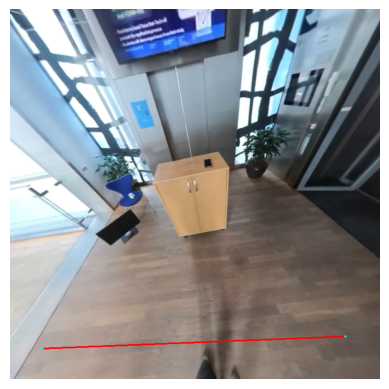

In [31]:
# reproject into frame to check results
new_contour_points_2d, new_contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation_new,
    cv_translation_new,
    K,
    next_image_chunk.image.shape[:2],
    cv_tris,
)
new_contour_overlay = next_image_chunk.image.copy()
new_contour = new_contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(new_contour_overlay, [new_contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in new_contour:
    cv2.circle(new_contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
display_image(new_contour_overlay)

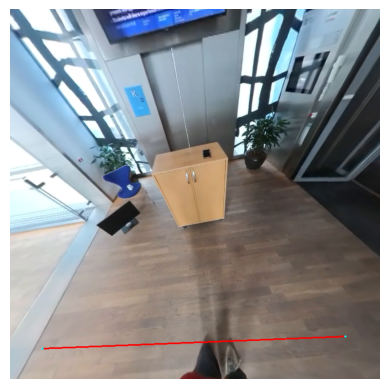

In [32]:
# compare against next frame
new_contour_overlay = next_next_image_chunk.image.copy()
new_contour = new_contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(new_contour_overlay, [new_contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in new_contour:
    cv2.circle(new_contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
display_image(new_contour_overlay)

Do next estimation step

In [23]:
from src.operations3d import estimate_pose_for_image_chunk
next_next_rotation_chunk, next_next_translation_chunk = estimate_pose_for_image_chunk(
    chunk=next_next_image_chunk,
    unposed_mesh_path=unposed_path,
    class_name=object_class,
    K=K,
    is_first_frame=False,
    da_env="da"
)
rot, trans = adjust_transforms_by_chunk_rotation([next_next_rotation_chunk], [next_next_translation_chunk], next_next_image_chunk)
next_next_rotation_world = rot[0]
next_next_translation_world = trans[0]

Running da_worker in conda environment 'da'...
[reset_object()] self.diameter:1.2711564909196753, vox_size:0.06355782454598377
[reset_object()] self.pts:torch.Size([659, 3])
[reset_object()] reset done
[make_rotation_grid()] cam_in_obs:(42, 4, 4)
[make_rotation_grid()] rot_grid:(252, 4, 4)
num original candidates = 252
num of pose after clustering: 252
[make_rotation_grid()] after cluster, rot_grid:(252, 4, 4)
[make_rotation_grid()] self.rot_grid: torch.Size([252, 4, 4])
[register()] Welcome
[register()] valid too small, return
[guess_translation()] valid is empty


In [24]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_next_rotation_world, next_next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)

In [25]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])